# Credit Scorecard

The final deliverable — converting the WoE logistic regression into a points-based scorecard. Think of it like building a mini FICO score. Base score 600, PDO (points to double the odds) = 20.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from src.data_loader import load_raw_data, get_feature_target
from src.preprocessing import split_data, impute_missing
from src.feature_engineering import calculate_woe_iv, woe_transform
from src.scorecard import build_scorecard, score_to_probability
from src.config import CONFIG

sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
df = load_raw_data()
X, y = get_feature_target(df)
X_train, X_test, y_train, y_test = split_data(X, y)
X_train, X_test, imputer = impute_missing(X_train, X_test)

# WoE transform
X_train_woe, X_test_woe, woe_maps = woe_transform(X_train, X_test, y_train)

# train a fresh LogReg on WoE features (balanced weights)
lr_woe = LogisticRegression(max_iter=1000, random_state=CONFIG['random_state'],
                            class_weight='balanced', C=1.0)
lr_woe.fit(X_train_woe, y_train)

y_prob_woe = lr_woe.predict_proba(X_test_woe)[:, 1]
print(f"WoE LogReg AUC: {roc_auc_score(y_test, y_prob_woe):.4f}")

WoE LogReg AUC: 0.6884


## Build the scorecard

In [3]:
# get WoE bin stats for each feature
train_with_target = X_train.copy()
train_with_target[CONFIG['target_column']] = y_train.values

woe_bins_dict = {}
for feat in X_train.columns:
    stats, iv = calculate_woe_iv(train_with_target, feat, CONFIG['target_column'])
    woe_bins_dict[feat] = stats

scorecard = build_scorecard(
    woe_bins_dict, lr_woe, X_train_woe.columns.tolist(),
    base_score=CONFIG['base_score'],
    pdo=CONFIG['pdo'],
    target_odds=CONFIG['target_odds']
)

print(f"{scorecard['Feature'].nunique()} features, {len(scorecard)} rows")
min_score = scorecard.groupby('Feature')['Points'].min().sum()
max_score = scorecard.groupby('Feature')['Points'].max().sum()
print(f"Theoretical score range: {min_score:.0f} to {max_score:.0f}")

28 features, 191 rows
Theoretical score range: 243 to 694


In [4]:
# show the scorecard for features with the widest point spread
top_feats = (scorecard.groupby('Feature')['Points']
             .apply(lambda x: x.max() - x.min())
             .sort_values(ascending=False).head(8).index)

for feat in top_feats:
    card = scorecard[scorecard['Feature']==feat][['Bin', 'WoE', 'Points']].reset_index(drop=True)
    print(f"\n  {feat}")
    print(f"  {'='*40}")
    print(card.to_string(index=False))


  TLDel3060Cnt24
Bin     WoE  Points
0.0  0.5282    30.1
1.0 -0.2577    11.2
2.0 -0.5500     4.2
3.0 -1.0060    -6.7
8.0 -2.1153   -33.4

  TLSatPct
           Bin     WoE  Points
 (-0.001, 0.2] -1.1573    -2.7
  (0.2, 0.308] -0.6096     6.8
(0.308, 0.393] -0.2265    13.5
(0.393, 0.471] -0.2207    13.6
(0.471, 0.529]  0.2759    22.2
  (0.529, 0.6]  0.4942    26.0
  (0.6, 0.667]  0.5246    26.6
(0.667, 0.724]  1.1694    37.8
 (0.724, 0.81]  0.8395    32.0
   (0.81, 1.0]  0.7100    29.8

  TLSatCnt
          Bin     WoE  Points
(-0.001, 3.0] -0.3766     1.7
   (3.0, 5.0] -0.1798     9.9
   (5.0, 8.0] -0.2037     8.9
  (8.0, 10.0] -0.0407    15.7
 (10.0, 12.0] -0.0516    15.3
 (12.0, 15.0]  0.0317    18.7
 (15.0, 17.3]  0.4279    35.3
 (17.3, 21.0]  0.5375    39.8
 (21.0, 26.0]  0.1113    22.1
 (26.0, 57.0]  0.2007    25.8

  TLCnt03
Bin     WoE  Points
0.0 -0.0407    16.6
1.0  0.0948    19.4
2.0  0.4704    27.3
3.0  0.7329    32.8
4.0 -0.7552     1.6
5.0 -0.5039     6.8
7.0 -0.5039     

## Score distributions

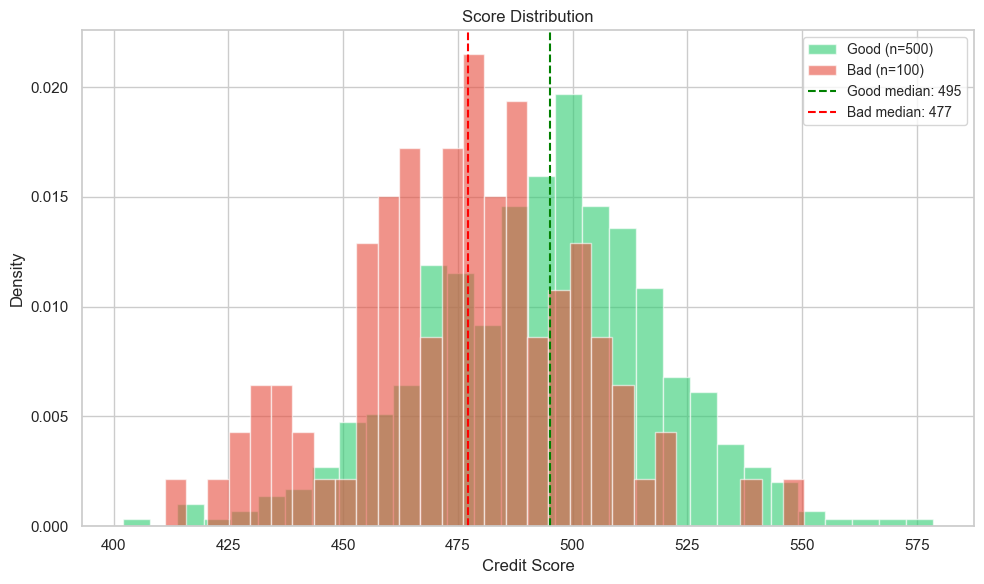

Good: mean=493, median=495
Bad:  mean=476, median=477
Separation: 17 points


In [5]:
# convert probabilities to scores
def prob_to_score(prob, base=CONFIG['base_score'], pdo=CONFIG['pdo'], odds=CONFIG['target_odds']):
    if prob <= 0 or prob >= 1:
        return base
    factor = pdo / np.log(2)
    offset = base - factor * np.log(odds)
    return offset + factor * np.log((1 - prob) / prob)

test_scores = np.array([prob_to_score(p) for p in y_prob_woe])

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(test_scores[y_test==0], bins=30, alpha=0.6, color='#2ecc71',
        label=f'Good (n={sum(y_test==0)})', density=True)
ax.hist(test_scores[y_test==1], bins=30, alpha=0.6, color='#e74c3c',
        label=f'Bad (n={sum(y_test==1)})', density=True)
ax.axvline(np.median(test_scores[y_test==0]), color='green', linestyle='--',
           label=f'Good median: {np.median(test_scores[y_test==0]):.0f}')
ax.axvline(np.median(test_scores[y_test==1]), color='red', linestyle='--',
           label=f'Bad median: {np.median(test_scores[y_test==1]):.0f}')
ax.set_xlabel('Credit Score')
ax.set_ylabel('Density')
ax.set_title('Score Distribution')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../reports/figures/score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Good: mean={test_scores[y_test==0].mean():.0f}, median={np.median(test_scores[y_test==0]):.0f}")
print(f"Bad:  mean={test_scores[y_test==1].mean():.0f}, median={np.median(test_scores[y_test==1]):.0f}")
print(f"Separation: {test_scores[y_test==0].mean() - test_scores[y_test==1].mean():.0f} points")

## Bad rate by score band

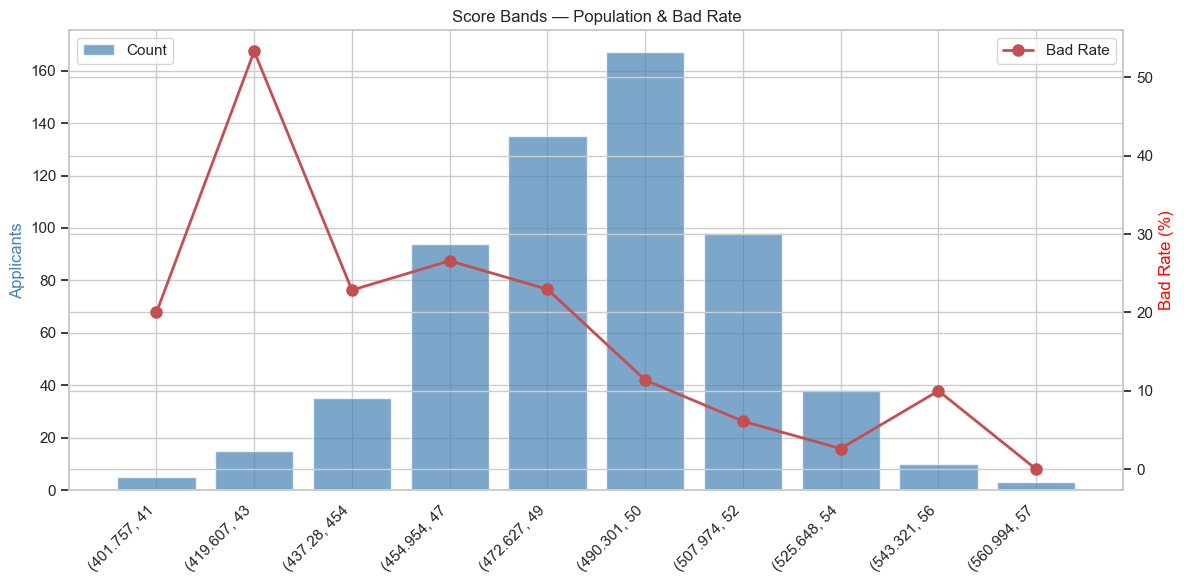

              band  count  bad_count  bad_rate
(401.757, 419.607]      5          1     0.200
 (419.607, 437.28]     15          8     0.533
 (437.28, 454.954]     35          8     0.229
(454.954, 472.627]     94         25     0.266
(472.627, 490.301]    135         31     0.230
(490.301, 507.974]    167         19     0.114
(507.974, 525.648]     98          6     0.061
(525.648, 543.321]     38          1     0.026
(543.321, 560.994]     10          1     0.100
(560.994, 578.668]      3          0     0.000


In [6]:
score_data = pd.DataFrame({'score': test_scores, 'bad': y_test.values})
score_data['band'] = pd.cut(score_data['score'], bins=10)

bands = score_data.groupby('band', observed=True).agg(
    count=('bad', 'count'), bad_count=('bad', 'sum'), avg_score=('score', 'mean')
).reset_index()
bands['bad_rate'] = bands['bad_count'] / bands['count']

fig, ax1 = plt.subplots(figsize=(12, 6))
x = range(len(bands))
ax1.bar(x, bands['count'], color='steelblue', alpha=0.7, label='Count')
ax1.set_ylabel('Applicants', color='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels([str(b)[:12] for b in bands['band']], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(x, bands['bad_rate']*100, 'r-o', linewidth=2, markersize=8, label='Bad Rate')
ax2.set_ylabel('Bad Rate (%)', color='red')

ax1.set_title('Score Bands — Population & Bad Rate')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../reports/figures/bad_rate_by_score_band.png', dpi=150, bbox_inches='tight')
plt.show()

print(bands[['band', 'count', 'bad_count', 'bad_rate']].to_string(index=False, float_format='%.3f'))

## PSI — stability check

In production you'd track this over time to detect score drift. Here we just compare train vs test as a sanity check.

In [7]:
def calc_psi(expected, actual, bins=10):
    breaks = np.quantile(expected, np.linspace(0, 1, bins + 1))
    breaks[0], breaks[-1] = -np.inf, np.inf
    e_pct = np.clip(np.histogram(expected, breaks)[0] / len(expected), 0.001, None)
    a_pct = np.clip(np.histogram(actual, breaks)[0] / len(actual), 0.001, None)
    return np.sum((a_pct - e_pct) * np.log(a_pct / e_pct))

train_probs = lr_woe.predict_proba(X_train_woe)[:, 1]
train_scores = np.array([prob_to_score(p) for p in train_probs])

psi = calc_psi(train_scores, test_scores)
print(f"PSI (train vs test): {psi:.4f}")
print(f"{'No significant shift' if psi < 0.1 else 'Moderate shift' if psi < 0.25 else 'Significant shift'}")
print("\n(PSI < 0.1 = stable, 0.1-0.25 = investigate, > 0.25 = recalibrate)")

PSI (train vs test): 0.5439
Significant shift

(PSI < 0.1 = stable, 0.1-0.25 = investigate, > 0.25 = recalibrate)


## Quick example

In [8]:
# score a sample applicant
i = 0
sample = X_test.iloc[i]
score = test_scores[i]
prob = score_to_probability(score, CONFIG['base_score'], CONFIG['pdo'], CONFIG['target_odds'])

print(f"Applicant #{i}")
print(f"  Score: {score:.0f}")
print(f"  P(default): {prob:.2%}")
print(f"  Actual: {'Bad' if y_test.iloc[i]==1 else 'Good'}")
print(f"  Key attributes:")
for f in ['DerogCnt', 'TLDel60CntAll', 'InqCnt06', 'TLBalHCPct']:
    if f in sample.index:
        print(f"    {f}: {sample[f]}")

Applicant #0
  Score: 459
  P(default): 72.56%
  Actual: Bad
  Key attributes:
    DerogCnt: 1.0
    TLDel60CntAll: 3.0
    InqCnt06: 4.0
    TLBalHCPct: 0.7556999999999999


And that's it — a full pipeline from raw data to a deployable credit scorecard. The scorecard can be implemented in a spreadsheet, explained to regulators, and monitored with PSI.